In [ ]:
#pip install scikit-learn

In [10]:
# MODEL DOWNLOADING LOCALLY AND THEN LOADING FROM CACHE

from pathlib import Path
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformer_lens import HookedTransformer
import transformer_lens.loading_from_pretrained as loading



MODEL_NAME = "Qwen/Qwen1.5-1.8B-Chat"
MODEL_PATH = "./models/Qwen__Qwen1.5-1.8B-Chat"
DTYPE = torch.float32
TRUST_REMOTE_CODE = False

def load_hooked_model(model_name, model_path=None, dtype=torch.float32, trust_remote_code=False):
    resolved_source = str(Path(model_path).expanduser().resolve()) if model_path else model_name
    model_load_kwargs = {
        "dtype": dtype,
        "trust_remote_code": trust_remote_code,
    }
    tokenizer_load_kwargs = {
        "trust_remote_code": trust_remote_code,
    }

    if model_path:
        model_load_kwargs["local_files_only"] = True
        tokenizer_load_kwargs["local_files_only"] = True

    hf_model = AutoModelForCausalLM.from_pretrained(resolved_source, **model_load_kwargs)
    tokenizer = AutoTokenizer.from_pretrained(resolved_source, **tokenizer_load_kwargs)

    if model_path:
        hf_cfg = hf_model.config.to_dict()
        cfg = loading.get_pretrained_model_config(
            resolved_source,
            hf_cfg=hf_cfg,
            fold_ln=True,
            dtype=dtype,
            local_files_only=True,
            trust_remote_code=trust_remote_code,
        )
        state_dict = loading.get_pretrained_state_dict(
            resolved_source,
            cfg,
            hf_model=hf_model,
            dtype=dtype,
            local_files_only=True,
            trust_remote_code=trust_remote_code,
        )
        model = HookedTransformer(
            cfg,
            tokenizer,
            move_to_device=False,
            default_padding_side="right",
        )
        model.load_and_process_state_dict(
            state_dict,
            fold_ln=True,
            center_writing_weights=True,
            center_unembed=True,
            fold_value_biases=True,
            refactor_factored_attn_matrices=False,
        )
        model.cfg.model_name = model_name.split("/")[-1]
        model.move_model_modules_to_device()
    else:
        model = HookedTransformer.from_pretrained(
            model_name,
            hf_model=hf_model,
            tokenizer=tokenizer,
            dtype=dtype,
            trust_remote_code=trust_remote_code,
        )

    print(f"Loaded {model_name} from {resolved_source}")
    print(f"TransformerLens config name: {model.cfg.model_name}")
    print(f"Layers: {model.cfg.n_layers} | Heads: {model.cfg.n_heads}")
    return model, tokenizer

model, tokenizer = load_hooked_model(
    MODEL_NAME,
    model_path=MODEL_PATH,
    dtype=DTYPE,
    trust_remote_code=TRUST_REMOTE_CODE,
)

Loaded Qwen/Qwen1.5-1.8B-Chat from /Users/tarunarora/Projects/macinter/models/Qwen__Qwen1.5-1.8B-Chat
TransformerLens config name: Qwen1.5-1.8B-Chat
Layers: 24 | Heads: 16


In [2]:
def explain_model(model):
    cfg = model.cfg
    print("="*50)
    print(f"Model Architecture Summary: {cfg.model_name}")
    print("="*50)
    print(f"Total Layers:       {cfg.n_layers}")
    
    # Identify layer types
    has_mlp = getattr(cfg, 'd_mlp', None) is not None
    layer_types = "Attention + MLP" if has_mlp else "Attention Only"
    print(f"Layer Type:         {layer_types}")
    
    print(f"Attention Heads:    {cfg.n_heads} per layer")
    print(f"Hidden Dimension:   {cfg.d_model} (d_model)")
    print(f"Head Dimension:     {cfg.d_head} (d_head)")
    
    if has_mlp:
        print(f"MLP Dimension:      {cfg.d_mlp} (d_mlp)")
        
    if getattr(cfg, 'd_vocab', None) is not None:
        print(f"Vocab Size:         {cfg.d_vocab}")
        
    print("\nLayer Structure Details")
    print("-----------------------")
    print("Each layer in this model consists of:")
    print("  1. Attention Block (Multi-Head Attention)")
    if has_mlp:
        print("  2. MLP Block (FeedForward Network)")
    print("  + LayerNorms applied to these components.")
    print("="*50)

def explain_model_detailed(model):
    # First, run the basic summary
    explain_model(model)
    
    cfg = model.cfg
    has_mlp = getattr(cfg, 'd_mlp', None) is not None
    is_parallel = getattr(cfg, 'parallel_attn_mlp', False)
    
    print("\n\n" + "="*50)
    print("DETAILED LAYER-BY-LAYER ARCHITECTURE")
    print("="*50)
    
    # Input embeddings representation
    print("[Input] → Token Embeddings & Positional Embeddings")
    print("   │")
    
    for i in range(cfg.n_layers):
        print(f"   ▼")
        print(f"╭── Layer {i} {'─'*35}")
        
        if is_parallel:
            # Parallel Attention + MLP Architecture (e.g. GPT-J, GPT-NeoX)
            print(f"│  ├─ [LayerNorm]")
            print(f"│  ├─ ┬─ [Attention Block] ({cfg.n_heads} heads, d_head={cfg.d_head})")
            if has_mlp:
                print(f"│  │  └─ [MLP Block]       (d_mlp={cfg.d_mlp})")
            print(f"│  └──≻ (Parallel outputs added to Residual Stream)")
        else:
            # Sequential Architecture (e.g. GPT-2, Llama, Qwen)
            print(f"│  ├─ [LayerNorm 1]")
            print(f"│  ├─ [Attention Block]  ({cfg.n_heads} heads, d_head={cfg.d_head})")
            print(f"│  │    ↳ added to Residual Stream")
            
            if has_mlp:
                print(f"│  │")
                print(f"│  ├─ [LayerNorm 2]")
                print(f"│  ├─ [MLP Block]        (d_mlp={cfg.d_mlp})")
                print(f"│  │    ↳ added to Residual Stream")
                
        print(f"╰──────────────────────────────────────────")
        print("   │")

    print("   ▼")
    print("╭── Final Output ─────────────────────────")
    print("│  ├─ [Final LayerNorm]")
    print("│  └─ [Unembedding] → (Output Logits)")
    print("╰─────────────────────────────────────────")
    print("="*50)


In [ ]:
explain_model_detailed(model)

### Common Functions used in Notebook

In [12]:
# Common Functions used in Notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"

def strip_token_text(s):
    return s.strip()
# Get the predicted next word given the prompt
def predict_next_token(prompt): 
    logits = model(prompt)
    last_logits = logits[0,-1 :]
    next_token_id = last_logits.argmax()
    next_token = model.to_string(next_token_id)
    return next_token

# Get the predicted next token_id given the prompt
def predict_next_token_id(prompt): 
    logits = model(prompt)
    last_logits = logits[0,-1 :]
    next_token_id = last_logits.argmax()
    return next_token_id

def predict_next_token_logit(prompt): 
    logits = model(prompt)
    last_logits = logits[0,-1 :]
    last_logit = last_logits.max()
    return last_logit

def get_answer_token_ids(model, clean_answer, corrupted_answer):
    return model.to_single_token(clean_answer), model.to_single_token(corrupted_answer)

def compute_answer_stats(model, clean_prompt, corrupted_prompt, clean_answer, corrupted_answer):
    clean_token_id, corrupted_token_id = get_answer_token_ids(model, clean_answer, corrupted_answer)

    clean_last = get_last_logits(model, clean_prompt)
    corrupted_last = get_last_logits(model, corrupted_prompt)

    clean_answer_str = strip_token_text(clean_answer)
    corrupted_answer_str = strip_token_text(corrupted_answer)

    clean_logit_clean = clean_last[clean_token_id].item()
    clean_logit_corrupted = clean_last[corrupted_token_id].item()
    corrupted_logit_clean = corrupted_last[clean_token_id].item()
    corrupted_logit_corrupted = corrupted_last[corrupted_token_id].item()

    baseline_clean = clean_logit_clean - clean_logit_corrupted
    baseline_corrupted = corrupted_logit_clean - corrupted_logit_corrupted
    full_range = baseline_clean - baseline_corrupted

    return {
        "clean_last": clean_last,
        "corrupted_last": corrupted_last,
        "clean_token_id": clean_token_id,
        "corrupted_token_id": corrupted_token_id,
        "clean_answer_str": clean_answer_str,
        "corrupted_answer_str": corrupted_answer_str,
        "clean_logit_clean": clean_logit_clean,
        "clean_logit_corrupted": clean_logit_corrupted,
        "corrupted_logit_clean": corrupted_logit_clean,
        "corrupted_logit_corrupted": corrupted_logit_corrupted,
        "baseline_clean": baseline_clean,
        "baseline_corrupted": baseline_corrupted,
        "full_range": full_range,
    }

def get_last_logits(model, prompt):
    logits = model(prompt)
    return logits[0, -1, :].squeeze(0)

def inspect_qk(model, layer, head):
    # Extract weight matrices — shape (d_model, d_head)
    W_Q = model.W_Q[layer, head].detach()  # (d_model, d_head)
    W_K = model.W_K[layer, head].detach()  # (d_model, d_head)
    
    # Combined QK matrix — shape (d_model, d_model)
    # This encodes: given two positions, how much does this head attend from one to the other?
    QK = W_Q @ W_K.T  # (d_model, d_model)
    
    # SVD — top singular vectors are the directions this head is most sensitive to
    U, S, Vh = torch.linalg.svd(QK)
    
    print(f"Layer {layer} Head {head} — QK matrix shape: {QK.shape}")
    print(f"Top 5 singular values: {S[:5].tolist()}")
    print()
    
    # Project top query/key directions back to token vocabulary
    # W_E = token embedding matrix, shape (vocab, d_model)
    W_E = model.embed.W_E.detach()  # (vocab, d_model)
    
    top_n = 10
    for i in range(3):  # top 3 singular directions
        query_dir = U[:, i]   # what the query is looking for
        key_dir   = Vh[i, :]  # what the key is offering
        
        # Which tokens project most onto these directions?
        query_scores = W_E @ query_dir  # (vocab,)
        key_scores   = W_E @ key_dir    # (vocab,)
        
        top_query_ids  = query_scores.topk(top_n).indices
        top_key_ids    = key_scores.topk(top_n).indices
        
        top_query_tokens = [model.to_string(t) for t in top_query_ids]
        top_key_tokens   = [model.to_string(t) for t in top_key_ids]
        
        print(f"Direction {i+1} (singular value: {S[i]:.2f})")
        print(f"  Query side (looking for): {top_query_tokens}")
        print(f"  Key side   (offering):    {top_key_tokens}")
        print()
def inspect_vout(model, layer, head):
    """
    W_V @ W_O for a single head.
    This is the matrix that maps from attended position's residual stream
    to the update written into the output residual stream.
    If this head copies fruit identity, top singular vectors should align
    with fruit token embeddings.
    """
    W_V = model.W_V[layer, head].detach()   # (d_model, d_head)
    W_O = model.W_O[layer, head].detach()   # (d_head, d_model)
    VO = W_V @ W_O                           # (d_model, d_model)
    
    U, S, Vh = torch.linalg.svd(VO)
    W_E = model.embed.W_E.detach()           # (vocab, d_model)
    
    print(f"Layer {layer} Head {head} — W_V @ W_O")
    print(f"Top 5 singular values: {S[:5].tolist()}")
    print()
    
    # Fruit tokens to check alignment against
    fruit_tokens = [" Mango", " Orange", " Peach", " Grape"]
    fruit_ids = [model.to_single_token(t) for t in fruit_tokens]
    fruit_embeds = W_E[fruit_ids]  # (4, d_model)
    
    top_n = 15
    for i in range(3):
        out_dir = Vh[i]  # direction written into residual stream output
        scores = W_E @ out_dir
        top_ids = scores.topk(top_n).indices
        top_tokens = [model.to_string(t) for t in top_ids]
        
        # Check if fruit tokens appear in top-n
        fruit_ranks = {}
        for fname, fid in zip(fruit_tokens, fruit_ids):
            rank = (scores.argsort(descending=True) == fid).nonzero()[0].item()
            fruit_ranks[fname.strip()] = rank
        
        print(f"Direction {i+1} (sv={S[i]:.2f})")
        print(f"  Top tokens written to output: {top_tokens}")
        print(f"  Fruit token ranks: {fruit_ranks}")
        print()

### Create our data set

In [13]:
from itertools import permutations

fruits = ["Peach", "Orange", "Grape", "Mango"]
dataset = []

for missing in fruits:
    listed = [f for f in fruits if f != missing]
    for perm in permutations(listed):
        a, b, c = perm
        prompt = f"Man has four fruits, {a}, {b}, {c} and {missing} - 1 {a} 1 {b} 1 {c} and 1"
        dataset.append({
            "prompt": prompt,
            "missing": missing,
            "label": fruits.index(missing)
        })

print(f"Total prompts: {len(dataset)}")
for d in dataset[:]:
    print(d)

Total prompts: 24
{'prompt': 'Man has four fruits, Orange, Grape, Mango and Peach - 1 Orange 1 Grape 1 Mango and 1', 'missing': 'Peach', 'label': 0}
{'prompt': 'Man has four fruits, Orange, Mango, Grape and Peach - 1 Orange 1 Mango 1 Grape and 1', 'missing': 'Peach', 'label': 0}
{'prompt': 'Man has four fruits, Grape, Orange, Mango and Peach - 1 Grape 1 Orange 1 Mango and 1', 'missing': 'Peach', 'label': 0}
{'prompt': 'Man has four fruits, Grape, Mango, Orange and Peach - 1 Grape 1 Mango 1 Orange and 1', 'missing': 'Peach', 'label': 0}
{'prompt': 'Man has four fruits, Mango, Orange, Grape and Peach - 1 Mango 1 Orange 1 Grape and 1', 'missing': 'Peach', 'label': 0}
{'prompt': 'Man has four fruits, Mango, Grape, Orange and Peach - 1 Mango 1 Grape 1 Orange and 1', 'missing': 'Peach', 'label': 0}
{'prompt': 'Man has four fruits, Peach, Grape, Mango and Orange - 1 Peach 1 Grape 1 Mango and 1', 'missing': 'Orange', 'label': 1}
{'prompt': 'Man has four fruits, Peach, Mango, Grape and Orange -

In [14]:
# Lets first check if our model predicts the correct output
# 1. Check model predicts correctly on all 24 prompts
correct = 0
for d in dataset:
    pred = predict_next_token(d["prompt"]).strip()
    match = pred == d["missing"]
    correct += match
    if not match:
        print(f"WRONG: expected {d['missing']}, got {pred} | {d['prompt'][:60]}")

print(f"\nAccuracy: {correct}/24")


Accuracy: 24/24


### GET FINAL POSITION VECTOR
Now extract residual stream activations at the final token position for every layer across all 24 prompts:

In [16]:
import torch
import numpy as np

all_activations = []  # shape will be (24, n_layers, d_model)
all_labels = []

for d in dataset:
    _, cache = model.run_with_cache(d["prompt"])
    
    prompt_activations = []
    for layer in range(model.cfg.n_layers):
        resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :].detach().cpu().numpy()
        prompt_activations.append(resid)
    
    all_activations.append(prompt_activations)
    all_labels.append(d["label"])

all_activations = np.array(all_activations)  # (24, 24, 2048)
all_labels = np.array(all_labels)            # (24,)

print(f"Activations shape: {all_activations.shape}")
print(f"Labels shape: {all_labels.shape}")
print(f"Label distribution: {np.bincount(all_labels)}")

Activations shape: (24, 24, 2048)
Labels shape: (24,)
Label distribution: [6 6 6 6]


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import pandas as pd

results = []
cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

for layer in range(model.cfg.n_layers):
    X = all_activations[:, layer, :]  # (24, 2048)
    y = all_labels

    fold_accs = []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf = LogisticRegression(max_iter=1000, C=1.0)
        clf.fit(X_train, y_train)
        fold_accs.append(clf.score(X_test, y_test))

    mean_acc = np.mean(fold_accs)
    results.append({"layer": layer, "accuracy": round(mean_acc, 4)})
    print(f"Layer {layer:2d} | accuracy: {mean_acc:.1%}")

df_probe = pd.DataFrame(results)

Layer  0 | accuracy: 100.0%
Layer  1 | accuracy: 100.0%
Layer  2 | accuracy: 100.0%
Layer  3 | accuracy: 100.0%
Layer  4 | accuracy: 100.0%
Layer  5 | accuracy: 100.0%
Layer  6 | accuracy: 100.0%
Layer  7 | accuracy: 100.0%
Layer  8 | accuracy: 100.0%
Layer  9 | accuracy: 100.0%
Layer 10 | accuracy: 100.0%
Layer 11 | accuracy: 100.0%
Layer 12 | accuracy: 100.0%
Layer 13 | accuracy: 100.0%
Layer 14 | accuracy: 100.0%
Layer 15 | accuracy: 100.0%
Layer 16 | accuracy: 100.0%
Layer 17 | accuracy: 100.0%
Layer 18 | accuracy: 100.0%
Layer 19 | accuracy: 100.0%
Layer 20 | accuracy: 100.0%
Layer 21 | accuracy: 100.0%
Layer 22 | accuracy: 100.0%
Layer 23 | accuracy: 100.0%


### Why is 100% at every layer wrong?
* Layer 0 is pure token embeddings — no attention head has run yet.
* The model cannot know which fruit is missing. 100% here means the
* probe found a surface signal, not the concept we are testing.
* First check: is this just overfitting on 24 points in 2048 dimensions?

In [25]:
from sklearn.utils import shuffle

# Sanity check — shuffle labels, accuracy should collapse to 25%
shuffled_labels = shuffle(all_labels, random_state=42)

fold_accs = []
for train_idx, test_idx in cv.split(all_activations[:, 0, :], shuffled_labels):
    X_train = all_activations[train_idx, 0, :]
    X_test = all_activations[test_idx, 0, :]
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, shuffled_labels[train_idx])
    fold_accs.append(clf.score(X_test, shuffled_labels[test_idx]))

print(f"Shuffled label accuracy at Layer 0: {np.mean(fold_accs):.1%}")

Shuffled label accuracy at Layer 0: 12.5%


### What the shuffled label check tells us
* 12.5% with random labels rules out pure overfitting — the 100% is real signal.
* But real signal from what? Same-class prompts share listed fruit tokens,
* so position -1 attended to similar things. The probe found token co-occurrence,
not missing fruit identity.

In [21]:
all_activations[1,1].shape

(2048,)

In [ ]:
# Train on Layer 12 specifically and save it # WHY - > Because my previous experiments uncovered that L12-Head 4 and 9 were responsbile for generating the final token
from sklearn.preprocessing import StandardScaler
layer = 12
X = all_activations[:, layer, :]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_scaled, all_labels)

fruit_names = ["Peach", "Orange", "Grape", "Mango"]

def predict_probe(prompt, layer=12):
    _, cache = model.run_with_cache(prompt)
    resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :].detach().cpu().numpy()
    resid_scaled = scaler.transform(resid.reshape(1, -1))
    
    raw_scores = clf.decision_function(resid_scaled)[0]
    predicted_label = clf.predict(resid_scaled)[0]
    predicted_fruit = fruit_names[predicted_label]
    
    print(f"Predicted: {predicted_fruit}")
    print(f"Raw scores: { {fruit_names[i]: round(raw_scores[i], 3) for i in range(4)} }")
    return predicted_fruit

# Test it
predict_probe("Man has four fruits, Peach, Orange, Grape and Mango - 1 Peach 1 Orange 1 Grape and 1")

Predicted: Mango
Raw scores: {'Peach': -1.241, 'Orange': -2.334, 'Grape': -1.858, 'Mango': 5.433}


'Mango'

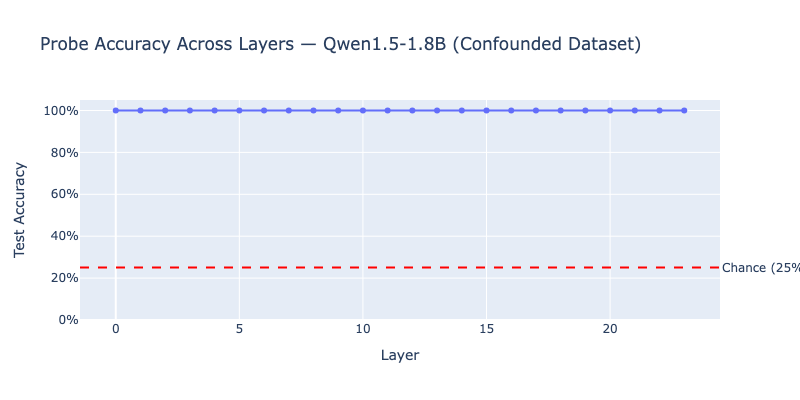

In [24]:
import plotly.express as px

fig = px.line(
    df_probe,
    x="layer",
    y="accuracy",
    title="Probe Accuracy Across Layers — Qwen1.5-1.8B (Confounded Dataset)",
    labels={"layer": "Layer", "accuracy": "Test Accuracy"},
    markers=True
)

fig.add_hline(y=0.25, line_dash="dash", line_color="red",
              annotation_text="Chance (25%)", annotation_position="right")

fig.update_yaxes(range=[0, 1.05], tickformat=".0%")
fig.update_layout(width=800, height=400)
fig.show()

### Why this dataset cannot be fixed
* Missing fruit and listed tokens are logical complements by task construction.
* Missing = Mango always means Listed = Peach, Orange, Grape. Always.
* No prompt redesign can break this correlation — they are the same information.
* Probing cannot cleanly test missing fruit identity on set-completion tasks.